# Data Extraction

In [5]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_channels.csv')

In [6]:
campaigns = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_campaigns.csv')
channels = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_channels.csv')
customers = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_customers.csv')
products = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_products.csv')
sales = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_sales.csv')
salesitems = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_salesitems.csv')
stock = pd.read_csv('/kaggle/input/datasets/joycemara/european-fashion-store-multitable-dataset/dataset_fashion_store_stock.csv')


# EDA

In [7]:
tables = ['campaigns', 'channels', 'customers', 'products', 'sales', 'salesitems', 'stock']

for table in tables:
    df = globals()[table]  
    print(f"\n{table.upper()}:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    


CAMPAIGNS:
Shape: (7, 7)
Columns: ['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel', 'discount_type', 'discount_value']

CHANNELS:
Shape: (2, 2)
Columns: ['channel', 'description']

CUSTOMERS:
Shape: (1000, 4)
Columns: ['customer_id', 'country', 'age_range', 'signup_date']

PRODUCTS:
Shape: (500, 9)
Columns: ['product_id', 'product_name', 'category', 'brand', 'color', 'size', 'catalog_price', 'cost_price', 'gender']

SALES:
Shape: (905, 7)
Columns: ['sale_id', 'channel', 'discounted', 'total_amount', 'sale_date', 'customer_id', 'country']

SALESITEMS:
Shape: (2253, 13)
Columns: ['item_id', 'sale_id', 'product_id', 'quantity', 'original_price', 'unit_price', 'discount_applied', 'discount_percent', 'discounted', 'item_total', 'sale_date', 'channel', 'channel_campaigns']

STOCK:
Shape: (1000, 3)
Columns: ['country', 'product_id', 'stock_quantity']


In [8]:
# Campaigns
print("CAMPAIGNS")
print("Date range:", campaigns['start_date'].min(), "to", campaigns['end_date'].max())
print("Channels used:", campaigns['channel'].value_counts().to_dict())
print("Discount types:", campaigns['discount_type'].value_counts().to_dict())

# Channels
print("\nCHANNELS")
print(channels)

# Customers
print("\nCUSTOMERS")
print("Countries:", customers['country'].value_counts().to_dict())
print("Age ranges:", customers['age_range'].value_counts().sort_index().to_dict())
print("Signup years:", pd.to_datetime(customers['signup_date']).dt.year.value_counts().sort_index().to_dict())

# Products
print("\nPRODUCTS")
print("Categories:", products['category'].value_counts().head().to_dict())
print("Brands (top 5):", products['brand'].value_counts().head().to_dict())
print("Gender split:", products['gender'].value_counts().to_dict())
print("Price stats – catalog: £{:.2f}, cost: £{:.2f}".format(
    products['catalog_price'].mean(), products['cost_price'].mean()))

# Sales
print("\nSALES")
print("Sale years:", pd.to_datetime(sales['sale_date']).dt.year.value_counts().sort_index().to_dict())
print("Channels:", sales['channel'].value_counts().to_dict())
print("Discounted sales (%):", round(sales['discounted'].mean() * 100, 1))
print("Total amount – mean: £{:.2f}, median: £{:.2f}".format(
    sales['total_amount'].mean(), sales['total_amount'].median()))
print("Countries:", sales['country'].value_counts().to_dict())

# SalesItems
print("\nSALESITEMS")
print("Items per sale (avg):", salesitems.groupby('sale_id').size().mean())
print("Discount applied (%):", round(salesitems['discount_applied'].mean() * 100, 1))
print("Channel-campaign usage:", salesitems['channel_campaigns'].value_counts().to_dict())
print("Top categories sold:", salesitems.merge(products[['product_id','category']], on='product_id')
      ['category'].value_counts().head().to_dict())

# Stock
print("\nSTOCK")
print("Countries with stock:", stock['country'].value_counts().to_dict())
print("Products per country (avg):", stock.groupby('country').size().mean())
print("Zero/low stock (<5 units):", (stock['stock_quantity'] < 5).sum())

CAMPAIGNS
Date range: 2025-04-01 to 2025-06-17
Channels used: {'Email': 3, 'Social Media': 2, 'App Mobile': 1, 'Website Banner': 1}
Discount types: {'Percentage': 5, 'Fixed': 2}

CHANNELS
      channel            description
0  E-commerce  Official online store
1  App Mobile       Brand mobile app

CUSTOMERS
Countries: {'France': 221, 'Germany': 212, 'Italy': 192, 'Netherlands': 162, 'Spain': 143, 'Portugal': 70}
Age ranges: {'16-25': 207, '26-35': 206, '36-45': 204, '46-55': 198, '56-65': 185}
Signup years: {2024: 336, 2025: 664}

PRODUCTS
Categories: {'Dresses': 109, 'T-Shirts': 108, 'Sleepwear': 104, 'Shoes': 100, 'Pants': 79}
Brands (top 5): {'Tiva': 500}
Gender split: {'Female': 500}
Price stats – catalog: £49.88, cost: £27.45

SALES
Sale years: {2025: 905}
Channels: {'E-commerce': 473, 'App Mobile': 432}
Discounted sales (%): 9.8
Total amount – mean: £358.27, median: £343.78
Countries: {'Germany': 212, 'France': 199, 'Italy': 170, 'Netherlands': 131, 'Spain': 113, 'Portugal': 80}

In [6]:
salesitems.sample(2)

,item_id,sale_id,product_id,quantity,original_price,unit_price,discount_applied,discount_percent,discounted,item_total,sale_date,channel,channel_campaigns
835,2787,1211,408,2,37.17,37.17,0.0,0.00%,0,74.34,2025-05-23,App Mobile,App Mobile
1061,3320,288,213,3,57.31,57.31,0.0,0.00%,0,171.93,2025-05-04,App Mobile,App Mobile


In [7]:
sales.sample(2)

,sale_id,channel,discounted,total_amount,sale_date,customer_id,country
901,993,E-commerce,0,311.37,2025-04-21,99,Spain
181,124,E-commerce,0,245.70,2025-04-19,99,Spain


In [53]:
products.sample()

,product_id,product_name,category,brand,color,size,catalog_price,cost_price,gender
485,486,T-Shirts Drop 4,T-Shirts,Tiva,Black,M,68.03,45.6,Female


/tmp/ipykernel_55/3042031612.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sales.resample('M', on='sale_date').agg(


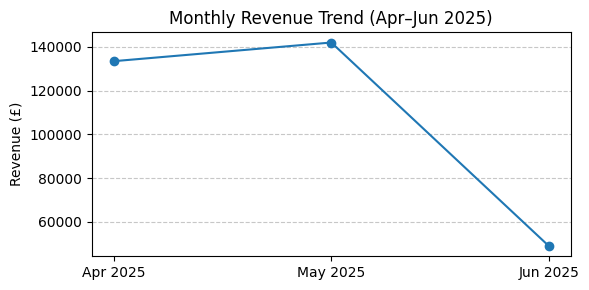

In [9]:
import matplotlib.pyplot as plt

# Ensure datetime
sales['sale_date'] = pd.to_datetime(sales['sale_date'])
monthly = sales.resample('M', on='sale_date').agg(
    transactions=('sale_id', 'count'),
    revenue=('total_amount', 'sum')
).reset_index()
monthly['month'] = monthly['sale_date'].dt.strftime('%b %Y')

plt.figure(figsize=(6, 3))
plt.plot(monthly['month'], monthly['revenue'], marker='o')
plt.title('Monthly Revenue Trend (Apr–Jun 2025)')
plt.ylabel('Revenue (£)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# Convert dates
sales['sale_date'] = pd.to_datetime(sales['sale_date'])
salesitems['sale_date'] = pd.to_datetime(salesitems['sale_date'])

In [11]:
# Convert discount_percent to Numeric

salesitems['discount_percent'] = salesitems['discount_percent'].str.replace('%', '', regex=False)
salesitems['discount_percent'] = pd.to_numeric(salesitems['discount_percent'], errors='coerce')

In [12]:
sales_per_category = (salesitems
          .merge(products, on='product_id')  
          .merge(sales, on='sale_id')       
          .groupby('category')['total_amount']
          .sum()
          .reset_index())

print("Total sales amount by Product category")
sales_per_category

Total sales amount by Product category


,category,total_amount
0,Dresses,180101.59
1,Pants,132688.89
2,Shoes,178671.77
3,Sleepwear,167882.53
4,T-Shirts,180994.98


In [13]:
# Sales Trend over time

monthly = sales.resample('ME', on='sale_date').agg(
    n_sales=('sale_id', 'count'),
    total_revenue=('total_amount', 'sum')
)
print(monthly)  # last 3 months

            n_sales  total_revenue
sale_date                         
2025-04-30      364      133392.44
2025-05-31      403      141922.21
2025-06-30      138       48922.01


In [14]:
# Customer Behavior (Purchases per customer)
cust_stats = sales.groupby('customer_id').agg(
    n_purchases=('sale_id', 'count'),
    total_spend=('total_amount', 'sum')
)

# Join with demographics
cust_demo = cust_stats.merge(customers[['customer_id', 'country', 'age_range']], on='customer_id')

print("Top countries by spend:")
print(cust_demo.groupby('country')['total_spend'].sum().sort_values(ascending=False))

print("\nAge range vs avg spend:")
print(cust_demo.groupby('age_range')['total_spend'].mean().sort_index())

Top countries by spend:
country
Germany        74590.69
France         72300.66
Italy          59458.11
Netherlands    46841.46
Spain          41114.79
Portugal       29930.95
Name: total_spend, dtype: float64

Age range vs avg spend:
age_range
16-25    568.261810
26-35    574.101736
36-45    560.424672
46-55    564.282973
56-65    525.861455
Name: total_spend, dtype: float64


In [15]:
# Product Performance
item_perf = salesitems.merge(products[['product_id', 'category', 'brand', 'catalog_price']], on='product_id')

print("Categories by units sold:")
print(item_perf.groupby('category')['quantity'].sum())

print("\nBrands by revenue:")
print((item_perf['quantity'] * item_perf['unit_price']).groupby(item_perf['brand']).sum())

print("\nAvg discount % by category:")
print(item_perf.groupby('category')['discount_percent'].mean().sort_values(ascending=False))

Categories by units sold:
category
Dresses      1451
Pants        1063
Shoes        1400
Sleepwear    1362
T-Shirts     1439
Name: quantity, dtype: int64

Brands by revenue:
brand
Tiva    324236.87
dtype: float64

Avg discount % by category:
category
Dresses      2.676349
T-Shirts     2.662602
Sleepwear    2.615385
Pants        2.215909
Shoes        1.758475
Name: discount_percent, dtype: float64


In [16]:
# Channel Usage
print("Sales by channel:")
print(sales['channel'].value_counts())

print("\nAvg order value by channel:")
print(sales.groupby('channel')['total_amount'].mean())

Sales by channel:
channel
E-commerce    473
App Mobile    432
Name: count, dtype: int64

Avg order value by channel:
channel
App Mobile    353.150324
E-commerce    362.950782
Name: total_amount, dtype: float64


In [17]:
# Compute total revenue per product
product_revenue = salesitems.groupby('product_id').apply(
    lambda x: (x['quantity'] * x['unit_price']).sum()
).reset_index(name='total_revenue')

high_rev = product_revenue.merge(
    products[['product_id', 'product_name', 'category']], 
    on='product_id'
).sort_values('total_revenue', ascending=False)

print("Top 5 High-Revenue Products:")
print(high_rev.head(5)[['product_name', 'category', 'total_revenue']])

Top 5 High-Revenue Products:
                   product_name  category  total_revenue
309     Relaxed Ribbed Trousers     Pants        2379.30
59            Modern Cotton Tee  T-Shirts        1919.95
115  Modern High-Waist Trousers     Pants        1907.66
467              Dresses Drop 1   Dresses        1858.32
458       Bold High-Waist Dress   Dresses        1804.08


/tmp/ipykernel_55/289884699.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  product_revenue = salesitems.groupby('product_id').apply(


# Modeling

## Predict whether a customer will make a repeat purchase within 60 days


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [19]:
#  Build labels for customers with at least one purchase
customer_purchases = sales.groupby('customer_id')['sale_date'].apply(
    lambda x: sorted(x)[:2]
).apply(pd.Series).rename(columns={0: 'first', 1: 'second'})

customer_purchases['repeat_within_60'] = (
    (customer_purchases['second'] - customer_purchases['first']).dt.days <= 60
) & (customer_purchases['second'].notna())

y = customer_purchases['repeat_within_60'].astype(int)

# Build features
rfm_features = sales.groupby('customer_id').agg(
    Recency=('sale_date', lambda x: (sales['sale_date'].max() - x.max()).days),
    Frequency=('sale_id', 'count'),
    Monetary=('total_amount', 'sum')
)

rfm_features = rfm_features.loc[y.index]

features = rfm_features.merge(
    customers[['customer_id', 'age_range', 'country']],
    left_index=True,
    right_on='customer_id',
    how='inner'
).set_index('customer_id')

features = pd.get_dummies(features, columns=['age_range', 'country'], drop_first=True)

X = features 

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}:\n", classification_report(y_test, y_pred))


Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       104
           1       0.99      1.00      0.99        70

    accuracy                           0.99       174
   macro avg       0.99      1.00      0.99       174
weighted avg       0.99      0.99      0.99       174


Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       104
           1       0.99      1.00      0.99        70

    accuracy                           0.99       174
   macro avg       0.99      1.00      0.99       174
weighted avg       0.99      0.99      0.99       174


K-Nearest Neighbors:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89       104
           1       0.83      0.86      0.85        70

    accuracy                           0.87       174
   macro avg       0.87      0.87      0.87       174
weighted av

## Predict Total Sale Amount


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sales['sale_date'] = pd.to_datetime(sales['sale_date'])
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])

# Start with sales as base
abt = sales.copy()

# Add campaign flag
def is_campaign_active(row):
    return campaigns[
        (campaigns['channel'] == row['channel']) &
        (row['sale_date'] >= campaigns['start_date']) &
        (row['sale_date'] <= campaigns['end_date'])
    ].shape[0] > 0

abt['campaign_active'] = abt.apply(is_campaign_active, axis=1).astype(int)

In [22]:
# Get dominant category per sale
sale_categories = salesitems.merge(products[['product_id', 'category']], on='product_id')
top_cat = sale_categories.groupby('sale_id').apply(
    lambda x: x['category'].mode().iloc[0] if not x['category'].mode().empty else 'Other'
).reset_index(name='top_category')

abt = abt.merge(top_cat, on='sale_id', how='left')

/tmp/ipykernel_55/551496350.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cat = sale_categories.groupby('sale_id').apply(


In [23]:
# Compute RFM at customer level
latest = sales['sale_date'].max()
rfm = sales.groupby('customer_id').agg(
    Recency=('sale_date', lambda x: (latest - x.max()).days),
    Frequency=('sale_id', 'count'),
    Monetary=('total_amount', 'sum')
)

# Merge into ABT
abt = abt.merge(rfm, on='customer_id', how='left')

In [24]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'channel', 'country', 'campaign_active', 'top_category']

X = abt[feature_cols]
y = abt['total_amount']

# One-hot encode categoricals
X = pd.get_dummies(X, columns=['channel', 'country', 'top_category'], drop_first=True)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name}:")
    print(f"  MAE: £{mae:.2f}")
    print(f"  R²: {r2:.3f}")


Linear Regression:
  MAE: £96.18
  R²: 0.401

Random Forest:
  MAE: £87.20
  R²: 0.311


In [29]:
if hasattr(models['Random Forest'], 'feature_importances_'):
    fi = pd.Series(
        models['Random Forest'].feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    print("\nTop 5 Predictive Features:")
    print(fi.head())


Top 5 Predictive Features:
Monetary              0.563837
Frequency             0.162873
Recency               0.081637
top_category_Pants    0.030077
channel_E-commerce    0.029845
dtype: float64


## Predict Product-Level Monthly Demand


In [30]:
# Merge salesitems & products 
si = salesitems.merge(products[['product_id', 'category', 'brand']], on='product_id')

si['sale_date'] = pd.to_datetime(si['sale_date'])
si['year_month'] = si['sale_date'].dt.to_period('M')

# Aggregate demand
demand = si.groupby(['product_id', 'year_month'])['quantity'].sum().reset_index()
demand['year_month'] = demand['year_month'].dt.to_timestamp()

In [31]:
# Historical trend
demand = demand.sort_values(['product_id', 'year_month'])
demand['prev_month_demand'] = demand.groupby('product_id')['quantity'].shift(1)
demand['rolling_2m_avg'] = demand.groupby('product_id')['quantity'].shift(1).rolling(2, min_periods=1).mean().reset_index(level=0, drop=True)

# Static product attributes
product_attrs = products[['product_id', 'category', 'brand']].drop_duplicates()
demand = demand.merge(product_attrs, on='product_id', how='left')

# Stock level
stock_agg = stock.groupby('product_id')['stock_quantity'].sum().reset_index()
demand = demand.merge(stock_agg, on='product_id', how='left')

# Campaign exposure
campaign_days = campaigns[['start_date', 'end_date', 'channel']].copy()
campaign_days['start_date'] = pd.to_datetime(campaign_days['start_date'])
campaign_days['end_date'] = pd.to_datetime(campaign_days['end_date'])

monthly_campaigns = []
for ym in demand['year_month'].dt.to_period('M').unique():
    start = ym.start_time
    end = ym.end_time
    active = ((campaign_days['start_date'] <= end) & (campaign_days['end_date'] >= start)).sum()
    monthly_campaigns.append({'year_month': start, 'campaign_days': active})

camp_df = pd.DataFrame(monthly_campaigns)
demand = demand.merge(camp_df, on='year_month', how='left')

In [32]:
model_data = demand.dropna(subset=['prev_month_demand']).copy()

# Encode categoricals
X = model_data[['prev_month_demand', 'rolling_2m_avg', 'stock_quantity', 'campaign_days', 'category', 'brand']]
X = pd.get_dummies(X, columns=['category', 'brand'], drop_first=True)

y = model_data['quantity']  # target: this month's demand

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name}:")
    print(f"  MAE (units): {mae:.1f}")
    print(f"  R²: {r2:.3f}")


Linear Regression:
  MAE (units): 2.9
  R²: 0.141

Random Forest:
  MAE (units): 2.8
  R²: 0.185


## Predict Customer Lifetime Value (CLV)


In [34]:
sales['sale_date'] = pd.to_datetime(sales['sale_date'])

history = sales[sales['sale_date'] < '2025-06-01']
target_month = sales[sales['sale_date'].dt.month == 6]

y = target_month.groupby('customer_id')['total_amount'].sum().reset_index()
y.rename(columns={'total_amount': 'clv_30d'}, inplace=True)

In [35]:
# RFM from Apr–May
latest_hist = history['sale_date'].max()
rfm = history.groupby('customer_id').agg(
    Recency=('sale_date', lambda x: (latest_hist - x.max()).days),
    Frequency=('sale_id', 'count'),
    Monetary=('total_amount', 'sum')
).reset_index()

# Add demographics
features = rfm.merge(customers[['customer_id', 'age_range', 'country']], on='customer_id', how='left')
campaign_customers = history[history['customer_id'].isin(campaigns['channel'])]['customer_id'].unique()  # simplified
model_data = features.merge(y, on='customer_id', how='inner')  # only customers active in Apr–May AND June

In [36]:
X = model_data[['Recency', 'Frequency', 'Monetary', 'age_range', 'country']]
X = pd.get_dummies(X, columns=['age_range', 'country'], drop_first=True)
y = model_data['clv_30d']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name}:")
    print(f"  MAE: £{mae:.2f}")
    print(f"  R²: {r2:.3f}")


Linear Regression:
  MAE: £207.49
  R²: -0.528

Random Forest:
  MAE: £229.79
  R²: -0.830


In [38]:
# Predict CLV for all Apr–May customers
all_customers_clv = model_data.copy()
all_customers_clv['predicted_clv'] = models['Random Forest'].predict(X)

print("Top Retention Targets:")
print(all_customers_clv.nlargest(20, 'predicted_clv')[['customer_id', 'predicted_clv']])

Top Retention Targets:
    customer_id  predicted_clv
24          397       550.4993
3            69       516.1620
63          864       476.8071
61          854       464.7761
35          499       461.8681
18          285       456.4308
10          201       455.0848
52          739       453.4525
9           168       449.2621
23          388       448.1535
11          217       447.5755
59          830       434.0856
49          699       433.9522
58          829       426.9274
53          780       425.2576
68          953       424.7788
64          876       423.9827
26          420       419.3337
39          570       419.2651
6           106       418.6294


# Analysis

## Sales forcasting

In [39]:
df = salesitems.merge(products[['product_id', 'category']], on='product_id')

# Convert date and extract year-month
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['year_month'] = df['sale_date'].dt.to_period('M')

# Aggregate monthly revenue per category
monthly_cat = df.groupby(['year_month', 'category'])['item_total'].sum().reset_index()
monthly_cat['year_month'] = monthly_cat['year_month'].dt.to_timestamp()

In [40]:
# Create a numeric time index
monthly_cat['time_idx'] = monthly_cat.groupby('category')['year_month'].rank(method='dense').astype(int)

In [41]:
forecasts = []

for cat in monthly_cat['category'].unique():
    cat_data = monthly_cat[monthly_cat['category'] == cat].copy()
    
    if len(cat_data) < 3:
        continue  # skip categories with too little history
    
    X = cat_data[['time_idx']].values
    y = cat_data['item_total'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Forecast next month (time_idx = max + 1)
    next_time = cat_data['time_idx'].max() + 1
    pred = model.predict([[next_time]])[0]
    
    forecasts.append({
        'category': cat,
        'last_month_revenue': cat_data['item_total'].iloc[-1],
        'forecast_next_month': max(pred, 0)  # no negative revenue
    })

forecast_df = pd.DataFrame(forecasts)
print(forecast_df)

    category  last_month_revenue  forecast_next_month
0    Dresses            11671.44          6092.170000
1      Pants             7681.98          3743.810000
2      Shoes             9838.22          3829.440000
3  Sleepwear             8764.51          3822.700000
4   T-Shirts            10221.20          6180.106667


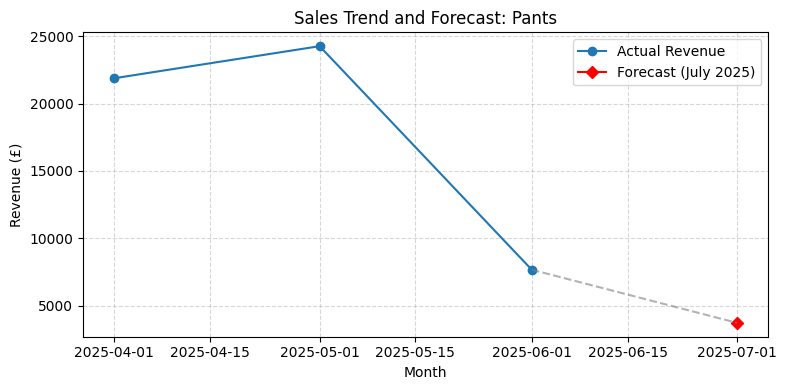

In [42]:
# Plot forecast
cat_example = 'Pants'
data = monthly_cat[monthly_cat['category'] == cat_example].copy()

# Get last observed date
last_date = data['year_month'].max()
# Add next month (July 2025)
next_date = last_date + pd.DateOffset(months=1)

# Get forecast value (from earlier `forecast_df`)
pred_val = forecast_df.loc[forecast_df['category'] == cat_example, 'forecast_next_month'].values[0]

# Plot actuals
plt.figure(figsize=(8, 4))
plt.plot(data['year_month'], data['item_total'], marker='o', label='Actual Revenue')

# Plot forecast as a single point at next month
plt.plot(next_date, pred_val, marker='D', color='red', label='Forecast (July 2025)')

# Optional: connect last actual to forecast with a dashed line
plt.plot([last_date, next_date], [data['item_total'].iloc[-1], pred_val],
         linestyle='--', color='gray', alpha=0.6)

plt.title(f'Sales Trend and Forecast: {cat_example}')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Compain Effectiveness Analysis

In [43]:
# Ensure datetime types
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])
sales['sale_date'] = pd.to_datetime(sales['sale_date'])

# Create all date-channel combinations covered by campaigns
campaign_days = []

for _, row in campaigns.iterrows():
    dates = pd.date_range(start=row['start_date'], end=row['end_date'], freq='D')
    for d in dates:
        campaign_days.append({
            'sale_date': d,
            'channel': row['channel'],
            'campaign_active': 1
        })

campaign_flag_df = pd.DataFrame(campaign_days)

In [44]:
# Aggregate sales by date + channel
daily_sales = sales.groupby(['sale_date', 'channel']).agg(
    n_transactions=('sale_id', 'count'),
    total_revenue=('total_amount', 'sum')
).reset_index()

# Merge with campaign flags
daily_sales = daily_sales.merge(
    campaign_flag_df, 
    on=['sale_date', 'channel'], 
    how='left'
).fillna({'campaign_active': 0})

daily_sales['campaign_active'] = daily_sales['campaign_active'].astype(int)

In [45]:
# Summary stats
summary = daily_sales.groupby('campaign_active').agg(
    days_observed=('sale_date', 'count'),
    total_transactions=('n_transactions', 'sum'),
    total_revenue=('total_revenue', 'sum'),
    avg_daily_revenue=('total_revenue', 'mean'),
    avg_transactions_per_day=('n_transactions', 'mean')
).round(2)

summary.index = ['Non-Campaign Periods', 'Campaign Periods']
print(summary)

                      days_observed  total_transactions  total_revenue  \
Non-Campaign Periods             95                 842      308411.79   
Campaign Periods                  7                  63       15824.87   

                      avg_daily_revenue  avg_transactions_per_day  
Non-Campaign Periods            3246.44                      8.86  
Campaign Periods                2260.70                      9.00  


In [46]:
from scipy.stats import mannwhitneyu

camp_rev = daily_sales[daily_sales['campaign_active'] == 1]['total_revenue']
non_camp_rev = daily_sales[daily_sales['campaign_active'] == 0]['total_revenue']

stat, p = mannwhitneyu(camp_rev, non_camp_rev, alternative='greater')
print(f"\nU-test: p-value = {p:.4f}")
print("Significant uplift?" if p < 0.05 else "No significant uplift")


U-test: p-value = 0.9780
No significant uplift


In [47]:
channel_effect = daily_sales.groupby(['channel', 'campaign_active'])['total_revenue'].mean().unstack()
channel_effect.columns = ['Non-Campaign', 'Campaign']
channel_effect['Uplift %'] = (channel_effect['Campaign'] - channel_effect['Non-Campaign']) / channel_effect['Non-Campaign'] * 100
print("\nChannel-wise Revenue Uplift:")
print(channel_effect)


Channel-wise Revenue Uplift:
            Non-Campaign     Campaign   Uplift %
channel                                         
App Mobile   3107.637955  2260.695714 -27.253569
E-commerce   3366.190588          NaN        NaN


## Inventory demand alignment 

In [48]:
# Total quantity sold per product (last 3 months)
demand = salesitems.groupby('product_id')['quantity'].sum().reset_index()
demand.rename(columns={'quantity': 'total_sold'}, inplace=True)

In [49]:
stock_total = stock.groupby('product_id')['stock_quantity'].sum().reset_index()

In [50]:
inventory_risk = pd.merge(demand, stock_total, on='product_id', how='outer')
inventory_risk.fillna(0, inplace=True)  # No sales → 0 demand; no stock → 0 stock

# Flag high-demand products
inventory_risk['high_demand'] = inventory_risk['total_sold'] >= inventory_risk['total_sold'].quantile(0.8)

# Flag low stock
inventory_risk['low_stock'] = (
    (inventory_risk['stock_quantity'] < 5) |
    (inventory_risk['stock_quantity'] < 0.1 * inventory_risk['total_sold'])
)

inventory_risk['stockout_risk'] = inventory_risk['high_demand'] & inventory_risk['low_stock']

In [51]:
# Merge with product info
risk_report = inventory_risk.merge(
    products[['product_id', 'product_name', 'category', 'brand']], 
    on='product_id'
)

high_risk_items = risk_report[risk_report['stockout_risk']].sort_values('total_sold', ascending=False)
print("Top Products at Risk of Lost Sales:")
print(high_risk_items[['product_name', 'category', 'total_sold', 'stock_quantity']].head(10))

Top Products at Risk of Lost Sales:
                  product_name  category  total_sold  stock_quantity
400       Elegant Cotton Dress   Dresses        35.0               2
279        Essential Linen Tee  T-Shirts        30.0               2
218        Polished Silk Shoes     Shoes        24.0               3
179   Vintage Sleeveless Shoes     Shoes        23.0               4
136     Classic Satin Trousers     Pants        23.0               2
369         Elegant Ribbed Tee  T-Shirts        22.0               3
230  Polished High-Waist Shoes     Shoes        21.0               4


In [52]:
n_high_demand = inventory_risk['high_demand'].sum()
n_at_risk = inventory_risk['stockout_risk'].sum()

print(f"\n- High-demand products (top 20%): {n_high_demand}")
print(f"- Of these, at risk of stockout: {n_at_risk} ({n_at_risk / n_high_demand:.1%})")


- High-demand products (top 20%): 107
- Of these, at risk of stockout: 7 (6.5%)


## Customer Lifetime Value (CLV) estimation

In [53]:
# Latest date in dataset (for Recency)
latest_date = sales['sale_date'].max()

# Aggregate RFM
rfm = sales.groupby('customer_id').agg(
    Recency=('sale_date', lambda x: (latest_date - x.max()).days),
    Frequency=('sale_id', 'count'),
    Monetary=('total_amount', 'sum')
).reset_index()

In [54]:
# Get first & last purchase per customer
purchase_dates = sales.groupby('customer_id')['sale_date'].agg(['min', 'max']).reset_index()
purchase_dates.rename(columns={'min': 'first_purchase', 'max': 'last_purchase'}, inplace=True)

# Merge with RFM
clv_df = rfm.merge(purchase_dates, on='customer_id')

# Compute months active (at least 1 month)
clv_df['months_active'] = (
    (clv_df['last_purchase'] - clv_df['first_purchase']).dt.days / 30
).clip(lower=1)

# Avg monthly spend
clv_df['avg_monthly_spend'] = clv_df['Monetary'] / clv_df['months_active']

# Assume lifespan = 6 months (conservative for fashion e-commerce; adjust based on domain knowledge)
clv_df['estimated_lifespan_months'] = 6

# Final CLV estimate
clv_df['CLV'] = clv_df['avg_monthly_spend'] * clv_df['estimated_lifespan_months']

In [55]:
clv_df = clv_df.merge(customers[['customer_id', 'country', 'age_range']], on='customer_id')

In [56]:
# Top high-CLV customers
print(clv_df.nlargest(10, 'CLV')[['customer_id', 'country', 'Monetary', 'CLV']])

# Avg CLV by country
print("\nAvg CLV by Country:")
print(clv_df.groupby('country')['CLV'].mean().sort_values(ascending=False))

# Correlation
print("\nCorrelation (Frequency vs CLV):", clv_df['Frequency'].corr(clv_df['CLV']))

     customer_id      country  Monetary           CLV
54            99        Spain   2678.59  16071.540000
321          564        Italy   1702.70  10216.200000
508          872  Netherlands   2221.05   9750.951220
470          816  Netherlands   1921.08   8866.523077
116          190        Italy   1722.06   8856.308571
198          346        Italy   1660.56   8791.200000
359          638       France   1456.35   8738.100000
502          861     Portugal   1454.31   8725.860000
133          220      Germany   2180.51   8532.430435
259          455  Netherlands   1366.00   8196.000000

Avg CLV by Country:
country
Portugal       3186.282268
France         3163.901152
Italy          3150.301443
Spain          3095.095262
Netherlands    3017.104927
Germany        2910.843631
Name: CLV, dtype: float64

Correlation (Frequency vs CLV): 0.7588949354815125


## churn risk detection

In [57]:
# Latest date in dataset
latest_date = sales['sale_date'].max()

# Recency = days since last purchase
recency = sales.groupby('customer_id')['sale_date'].max().reset_index()
recency['Recency'] = (latest_date - recency['sale_date']).dt.days
recency = recency[['customer_id', 'Recency']]

In [58]:
recency['churn_risk'] = recency['Recency'] >= 60
# Merge with customer demographics
churn_df = recency.merge(customers[['customer_id', 'country', 'age_range']], on='customer_id')

# Count by segment
print("Churn Risk Summary:")
print(f"Total customers: {len(churn_df)}")
print(f"At-risk (inactive ≥90 days): {churn_df['churn_risk'].sum()} ({churn_df['churn_risk'].mean():.1%})")

print("\nTop countries with at-risk customers:")
print(churn_df[churn_df['churn_risk']].groupby('country').size().sort_values(ascending=False))

Churn Risk Summary:
Total customers: 580
At-risk (inactive ≥90 days): 57 (9.8%)

Top countries with at-risk customers:
country
Germany        19
France         14
Netherlands     9
Portugal        6
Italy           5
Spain           4
dtype: int64


In [59]:
spend = sales.groupby('customer_id')['total_amount'].sum().reset_index()
churn_df = churn_df.merge(spend, on='customer_id', how='left')
churn_df['total_amount'] = churn_df['total_amount'].fillna(0)

# Top high-spend customers at risk
high_value_churn = churn_df[
    (churn_df['churn_risk']) & 
    (churn_df['total_amount'] > churn_df['total_amount'].quantile(0.7))
].nlargest(20, 'total_amount')

print("\nTop High-Value Customers at Risk (Retention Priority):")
print(high_value_churn[['customer_id', 'country', 'Recency', 'total_amount']])


Top High-Value Customers at Risk (Retention Priority):
     customer_id   country  Recency  total_amount
118          192     Spain       60       1327.03
78           132    France       60        760.40
363          642  Portugal       63        747.50
577          996   Germany       72        699.55


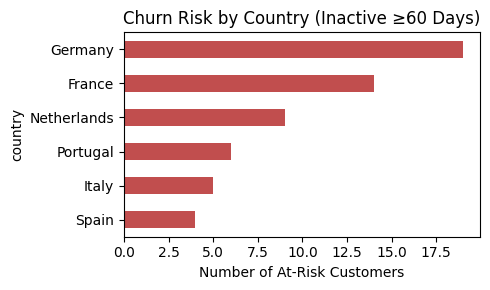

In [68]:
# Merge with customers to get country
at_risk = recency[recency['churn_risk']].merge(customers[['customer_id', 'country']], on='customer_id')
risk_by_country = at_risk['country'].value_counts().sort_values()

plt.figure(figsize=(5, 3))
risk_by_country.plot(kind='barh', color='firebrick', alpha=0.8)
plt.xlabel('Number of At-Risk Customers')
plt.title('Churn Risk by Country (Inactive ≥60 Days)')
plt.tight_layout()
plt.show()

## K-Means clustering on RFM features 

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sales['sale_date'] = pd.to_datetime(sales['sale_date'])

# Compute latest date in dataset
latest_date = sales['sale_date'].max()

# Build RFM
rfm = sales.groupby('customer_id').agg(
    Recency=('sale_date', lambda x: (latest_date - x.max()).days),
    Frequency=('sale_id', 'count'),
    Monetary=('total_amount', 'sum')
).reset_index()  # Keep customer_id as a column for now

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [29]:
from sklearn.metrics import silhouette_score

# Compute WCSS and silhouette
wcss = []
silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans_temp.fit_predict(rfm_scaled)
    wcss.append(kmeans_temp.inertia_)  # WCSS
    silhouette_scores.append(silhouette_score(rfm_scaled, cluster_labels))


# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}, Silhouette Score={score:.2f}")

k=2, Silhouette Score=0.43
k=3, Silhouette Score=0.38
k=4, Silhouette Score=0.44
k=5, Silhouette Score=0.38
k=6, Silhouette Score=0.36


In [30]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze clusters
cluster_summary = rfm.groupby('cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_id': 'count'
}).round(2)

print(cluster_summary)

         Recency  Frequency  Monetary  customer_id
cluster                                           
0          56.36       1.12    384.29          182
1          18.98       2.07    742.70          164
2          23.41       3.45   1348.40           51
3          20.24       1.02    348.23          183


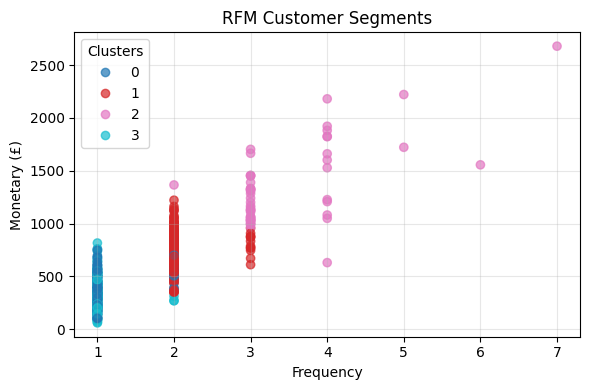

In [64]:
# Plot
plt.figure(figsize=(6, 4))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('Monetary (£)')
plt.title('RFM Customer Segments')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---